In [2]:
# 공공데이터 스타일 데이터 생성 (따릉이 일별 대여 기록 — 가상)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(7)
n_days = 180
dates = pd.date_range("2025-01-01", periods=n_days, freq="D")
# 계절성: 봄·여름에 대여 증가
seasonal = 3000 + 2500 * np.sin(np.linspace(0, np.pi, n_days))
rentals = (seasonal + np.random.normal(0, 400, n_days)).round().astype(int)

bike = pd.DataFrame({
    "date": dates,
    "rentals": rentals,
    "avg_temp": (np.linspace(-2, 28, n_days) + np.random.normal(0, 2, n_days)).round(1),
    "rainfall": np.random.choice([0, 0, 0, 0, 5, 12, 30], n_days),
    "station_area": np.random.choice(["강남", "마포", "송파", "종로", " 강남 "], n_days),
})
# 오염 심기: 대여수 결측, 기온 이상치, 중복 행
bike.loc[np.random.choice(n_days, 8, replace=False), "rentals"] = np.nan
bike.loc[50, "avg_temp"] = 250.0     # 센서 오류로 보이는 이상치
bike = pd.concat([bike, bike.iloc[[3]]], ignore_index=True)  # 중복 1건

print("따릉이 데이터 준비 완료:", bike.shape)
bike.head()

따릉이 데이터 준비 완료: (181, 5)


,date,rentals,avg_temp,rainfall,station_area
0,2025-01-01,3676.0,-3.0,12,마포
1,2025-01-02,2857.0,-1.1,0,마포
2,2025-01-03,3101.0,-1.1,0,강남
3,2025-01-04,3295.0,0.9,0,강남
4,2025-01-05,2860.0,-1.1,0,마포


In [7]:
print("shape:", bike.shape)

bike.info()

display(bike.describe())
# date 열은 datetime64으로 인식됨. rentals 열은 float64, avg_temp 열은 float64, rainfall 열은 int64, station_area 열은 str 문자열로 인식됨.
# 수치 요약에서 avg_temp의 최댓값이 250. 평균이 14이고, 기온이라는 특수성을 고려했을때 이상치 의심.
# rental 열에서 8개의 결측치 확인 (count 개수 타 열과 불일치)/ 건수가 생긱보다 많아서 놀랐다. 

shape: (181, 5)
<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          181 non-null    datetime64[us]
 1   rentals       173 non-null    float64       
 2   avg_temp      181 non-null    float64       
 3   rainfall      181 non-null    int64         
 4   station_area  181 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 7.2 KB


,date,rentals,avg_temp,rainfall
count,181,173.000000,181.000000,181.000000
mean,2025-03-31 00:31:49.392265,4531.757225,14.169061,5.298343
min,2025-01-01 00:00:00,2514.000000,-4.900000,0.000000
25%,2025-02-14 00:00:00,3841.000000,5.100000,0.000000
50%,2025-03-31 00:00:00,4708.000000,13.100000,0.000000
75%,2025-05-15 00:00:00,5243.000000,20.600000,5.000000
max,2025-06-29 00:00:00,6388.000000,250.000000,30.000000
std,NaN,889.609013,19.742786,9.687303


In [8]:
print("[결측치]")
print(bike.isnull().sum())
print("\n중복 행:", bike.duplicated().sum())
print("\n[station_area 값의 종류]")
print(bike["station_area"].unique())
print("\n기온 이상치 확인(상위 3개):")
print(bike["avg_temp"].sort_values(ascending=False).head(3).tolist())

[결측치]
date            0
rentals         8
avg_temp        0
rainfall        0
station_area    0
dtype: int64

중복 행: 1

[station_area 값의 종류]
<StringArray>
['마포', ' 강남 ', '강남', '송파', '종로']
Length: 5, dtype: str

기온 이상치 확인(상위 3개):
[250.0, 31.8, 30.6]


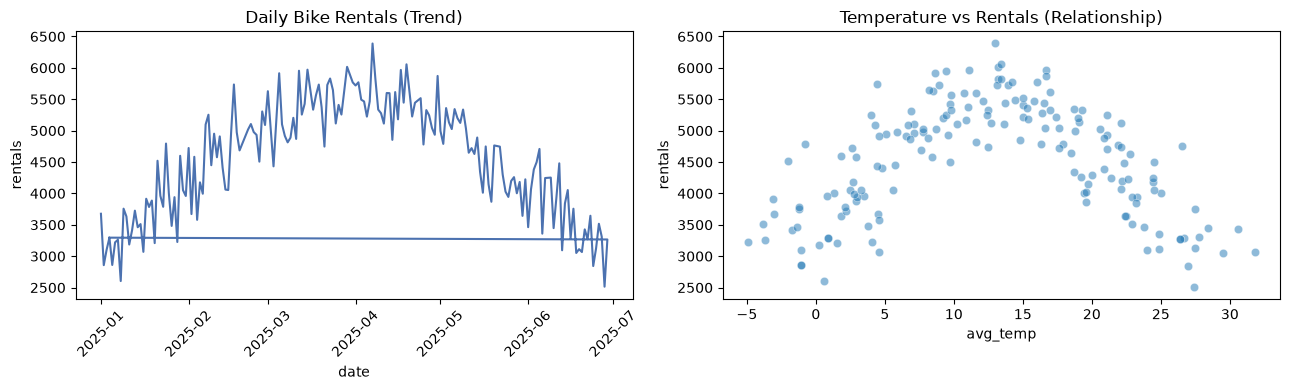

In [5]:
clean = bike[(bike["avg_temp"] < 60)].dropna(subset=["rentals"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# 추이
axes[0].plot(clean["date"], clean["rentals"], color="#4C72B0")
axes[0].set_title("Daily Bike Rentals (Trend)")
axes[0].set_xlabel("date"); axes[0].set_ylabel("rentals")
axes[0].tick_params(axis="x", rotation=45)
# 관계
sns.scatterplot(data=clean, x="avg_temp", y="rentals", alpha=0.5, ax=axes[1])
axes[1].set_title("Temperature vs Rentals (Relationship)")
axes[1].set_xlabel("avg_temp"); axes[1].set_ylabel("rentals")
plt.tight_layout(); plt.show()



In [17]:
bike["rainfall"].value_counts()

rainfall
0     118
5      25
30     21
12     17
Name: count, dtype: int64

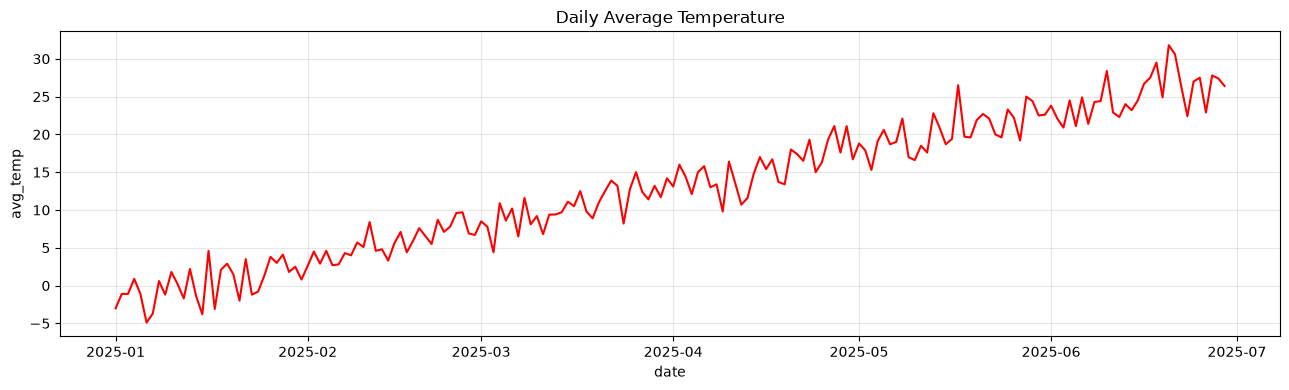

In [27]:
# 날짜 형식 변환
bike["date"] = pd.to_datetime(bike["date"])

# 평균 온도 250 제거
clean_temp = bike[bike["avg_temp"] != 250]

# 날짜별 평균 온도 계산
daily_temp = clean_temp.groupby("date")["avg_temp"].mean().reset_index()

# 그래프
plt.figure(figsize=(13, 4))

plt.plot(
    daily_temp["date"],
    daily_temp["avg_temp"],
    color="#FE0000"
)

plt.title("Daily Average Temperature")
plt.xlabel("date")
plt.ylabel("avg_temp")

plt.xticks(rotation=0)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()